In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'

import torch
import torch.nn as nn
import torch.nn.init as init
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import copy
import time
from typing import Any, Dict, List, Optional, Tuple, Union
from pathlib import Path
import kagglehub

# Check hardware - if this shows 'cpu', the training will be slow but more stable
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Helper to ensure a directory exists
def _ensure_dir(p):
    Path(p).mkdir(parents=True, exist_ok=True)

Using device: cuda


In [2]:
def plot_lr_schedule(
    lr_history: List[float],
    save_path: Optional[str] = None,
    title: str = "Learning Rate Decay vs. Epochs",
) -> None:
    """Plot the learning-rate schedule across training epochs."""
    if save_path is None:
        _ensure_dir(RESULTS_DIR)
        save_path = os.path.join(str(RESULTS_DIR), "lr_schedule.png")

    epochs = list(range(1, len(lr_history) + 1))
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(epochs, lr_history, marker="o", linewidth=2, color="#1f77b4")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Learning Rate")
    ax.set_title(title)
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.close(fig)
    print(f"LR schedule plot saved → {save_path}")
    plt.show()


def plot_training_curves(
    history: Dict[str, List[float]],
    model_name: str = "model",
    save_dir: Optional[Union[str, Path]] = None,
) -> None:
    """Plot train/val loss and accuracy curves side by side."""
    if save_dir is None:
        save_dir = RESULTS_DIR
    _ensure_dir(save_dir)

    epochs = list(range(1, len(history["train_loss"]) + 1))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    ax1.plot(epochs, history["train_loss"], label="Train Loss")
    ax1.plot(epochs, history["val_loss"], label="Val Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title(f"{model_name} — Loss")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Accuracy
    ax2.plot(epochs, history["train_acc"], label="Train Acc")
    ax2.plot(epochs, history["val_acc"], label="Val Acc")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy (%)")
    ax2.set_title(f"{model_name} — Accuracy")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    fig.tight_layout()
    fname = Path(save_dir) / f"{model_name}_curves.png"
    fig.savefig(str(fname), dpi=150)
    plt.close(fig)
    print(f"Training curves saved → {fname}")
    # Display the plot of training curves using plt.show()
    plt.show()

In [3]:
#region CoBo Model
# YoLo copy -- Cats Only Bark Once
class coboCNN(nn.Module):
    __name__ = "coboCNN"
    def __init__(self, num_classes: int = 2):
        super().__init__()
        
        
        self.cobo = nn.Sequential(
            # dont forget activations
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1), 
            nn.BatchNorm2d(16),
            nn.AvgPool2d(kernel_size=2, stride=2, padding=0),
            nn.ReLU(),
            
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.AvgPool2d(kernel_size=2, stride=2, padding=0),
            nn.ReLU(),
            
            nn.Conv2d(32,64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.AvgPool2d(kernel_size=2, stride=2, padding=0),
            nn.ReLU(),
            
            nn.Conv2d(64,64,kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.AvgPool2d(kernel_size=2, stride=2, padding=0),
            nn.ReLU(),
            
            nn.Conv2d(64, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
        )
        
        # LeNet-5 Original classifier
        self.classifier = nn.Sequential(
            nn.Linear(1_568, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 343),
            nn.Sigmoid()
        )

        # Apply initialization
        self._apply_kaiming_init()
        
    def _apply_kaiming_init(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                w = getattr(m, 'weight', None)
                b = getattr(m, 'bias', None)
                if w is not None:
                    nn.init.kaiming_uniform_(w, nonlinearity='relu')
                if b is not None:
                    nn.init.constant_(b, 0)
            else:
                b = getattr(m, 'bias', None)
                if b is not None:
                    try:
                        nn.init.constant_(b, 0)
                    except Exception:
                        pass

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.cobo(x)
        x = x.view(x.size(0), -1) # Flattens feature maps
        x = self.classifier(x)
        return x
#endregion

In [4]:
# Download the dataset locally
dataset_dir = Path(kagglehub.dataset_download("andrewmvd/dog-and-cat-detection"))
print(f"Dataset downloaded to: {dataset_dir.resolve()}")

# Preview top-level files/folders.
for item in sorted(dataset_dir.iterdir()):
    print(f"- {item.name}")

Dataset downloaded to: C:\Users\kiann\.cache\kagglehub\datasets\andrewmvd\dog-and-cat-detection\versions\1
- annotations
- annotations.csv
- images


In [5]:
# Try to import refactored utilities from repo; fallback to definitions below
try:
    import importlib
    dp = importlib.import_module('src.data_processing')
    resize_and_pad_image = dp.resize_and_pad_image
    transform_bbox = dp.transform_bbox
    process_record = dp.process_record
    split_train_val = dp.split_train_val
    visualize_sample = dp.visualize_sample
except Exception:
    from sklearn.model_selection import train_test_split
    from tqdm import tqdm
    import random
    import xml.etree.ElementTree as ET

    def _get_bilinear():
        try:
            return Image.Resampling.BILINEAR
        except Exception:
            return getattr(Image, 'BILINEAR', 2)

    def resize_and_pad_image(img: Image.Image, size=(112,112)):
        W,H = size; w,h = img.size
        scale = min(W/w, H/h)
        new_w = max(1, int(round(w*scale)))
        new_h = max(1, int(round(h*scale)))
        img_resized = img.resize((new_w, new_h), resample=_get_bilinear())
        pad_left = (W - new_w) // 2; pad_top = (H - new_h) // 2
        canvas = Image.new("RGB", (W, H), (0,0,0))
        canvas.paste(img_resized, (pad_left, pad_top))
        return canvas, scale, pad_left, pad_top

    def transform_bbox(bbox, scale, pad_left, pad_top):
        xmin, ymin, xmax, ymax = bbox
        return (
            max(0, int(round(xmin*scale + pad_left))),
            max(0, int(round(ymin*scale + pad_top))),
            max(0, int(round(xmax*scale + pad_left))),
            max(0, int(round(ymax*scale + pad_top)))
        )

    def process_record(image_path, bbox, out_path, size=(112,112)):
        img = Image.open(image_path).convert("RGB")
        orig_w, orig_h = img.size
        canvas, scale, pad_left, pad_top = resize_and_pad_image(img, size=size)
        xmin, ymin, xmax, ymax = transform_bbox(bbox, scale, pad_left, pad_top)
        out_path.parent.mkdir(parents=True, exist_ok=True)
        canvas.save(out_path)
        return {
            "image_path": str(out_path),
            "orig_w": orig_w,
            "orig_h": orig_h,
            "scale": float(scale),
            "pad_left": int(pad_left),
            "pad_top": int(pad_top),
            "xmin": int(xmin),
            "ymin": int(ymin),
            "xmax": int(xmax),
            "ymax": int(ymax)
        }

    def split_train_val(df, stratify_col="label", val_frac=0.2, random_state=42):
        if stratify_col in df.columns:
            t, v = train_test_split(df, test_size=val_frac, stratify=df[stratify_col], random_state=random_state)
        else:
            t, v = train_test_split(df, test_size=val_frac, random_state=random_state)
        return t.reset_index(drop=True), v.reset_index(drop=True)

    def visualize_sample(img_path, bbox, ax=None, show=False):
        if ax is None:
            fig, ax = plt.subplots()
        img = plt.imread(img_path)
        ax.imshow(img)
        import matplotlib.patches as patches
        xmin, ymin, xmax, ymax = bbox
        rect = patches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin,
                                linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        if show:
            plt.show()


In [6]:
for p in dataset_dir.rglob("*.csv"):
    df_check = pd.read_csv(p, nrows=0) # Only reads header
    print(f"File: {p.name} | Columns: {list(df_check.columns)}")

File: annotations.csv | Columns: ['filename', 'class', 'xmin', 'ymin', 'xmax', 'ymax']


In [7]:
# Cache the parsed XML annotations (always load into `df` for later cells)
from tqdm import tqdm
import xml.etree.ElementTree as ET

# Determine repo root robustly (works if CWD is repo root or notebooks/)
cwd = Path.cwd()
repo_root = cwd if (cwd / "notebooks").exists() else (cwd.parent if cwd.name == "notebooks" else cwd)

cache_path = repo_root / "outputs" / "processed_data.csv"
cache_path.parent.mkdir(parents=True, exist_ok=True)

if cache_path.exists():
    print(f"Loading processed data from {cache_path}")
    df = pd.read_csv(cache_path)
else:
    print("Processing XML files...")
    xml_files = list(dataset_dir.rglob("*.xml"))
    print(f"Found {len(xml_files)} XML files.")

    data = []
    for xml_path in tqdm(xml_files, desc="Processing XMLs"):
        try:
            tree = ET.parse(xml_path)
            root = tree.getroot()
        except Exception:
            continue

        fname_node = root.find("filename")
        file_name = fname_node.text if fname_node is not None and fname_node.text else Path(xml_path).stem

        for obj in root.findall("object"):
            name_node = obj.find("name")
            label = name_node.text if name_node is not None and name_node.text else "unknown"
            bbox = obj.find("bndbox")
            if bbox is None:
                continue

            xmin_n = bbox.find("xmin")
            ymin_n = bbox.find("ymin")
            xmax_n = bbox.find("xmax")
            ymax_n = bbox.find("ymax")
            if None in (xmin_n, ymin_n, xmax_n, ymax_n):
                continue

            try:
                xmin = int(getattr(xmin_n, "text", "0") or "0")
                ymin = int(getattr(ymin_n, "text", "0") or "0")
                xmax = int(getattr(xmax_n, "text", "0") or "0")
                ymax = int(getattr(ymax_n, "text", "0") or "0")
            except Exception:
                continue

            data.append({
                "filename": file_name,
                "class": label,
                "xmin": xmin,
                "ymin": ymin,
                "xmax": xmax,
                "ymax": ymax,
            })

    df = pd.DataFrame(data)
    print(f"\nLoaded annotations shape: {df.shape}")
    print(df.head())
    df.to_csv(cache_path, index=False)
    print(f"Processed data saved to {cache_path}")

Loading processed data from c:\Users\kiann\Documents\.Education\UU\Courses\INFOCV\Assignments\04_UU_CV_Dog_Cat_Object_Detection\outputs\processed_data.csv


In [8]:
# Expected final columns: image, label, xmin, ymin, xmax, ymax
colmap = {}
if "file_name" in df.columns and "label" in df.columns:
    colmap["file_name"] = "image"
if "image" not in df.columns:
    colmap[df.columns[0]] = "image"
if "class" in df.columns:
    colmap["class"] = "label"
if "x1" in df.columns:
    colmap["x1"] = "xmin"
if "y1" in df.columns:
    colmap["y1"] = "ymin"
if "x2" in df.columns:
    colmap["x2"] = "xmax"
if "y2" in df.columns:
    colmap["y2"] = "ymax"
df = df.rename(columns=colmap)

required = {"image", "label", "xmin", "ymin", "xmax", "ymax"}
if not required.issubset(set(df.columns)):
    raise ValueError(f"Annotations missing required columns: {required - set(df.columns)}")

def _resolve_image_path(p: str) -> str:
    pp = Path(str(p))
    # If it's already an existing absolute path, keep it.
    if pp.is_absolute() and pp.exists():
        return str(pp)

    # Try relative paths inside the kaggle dataset folder.
    cand1 = dataset_dir / pp
    if cand1.exists():
        return str(cand1)

    # Common layout for this dataset: dataset_dir/images/<filename>
    cand2 = dataset_dir / "images" / pp.name
    if cand2.exists():
        return str(cand2)

    # If p already included a subdir like images/..., try that too.
    cand3 = dataset_dir / "images" / pp
    if cand3.exists():
        return str(cand3)

    # Fallback (so later code has a deterministic target)
    return str(cand2)

df["image"] = df["image"].apply(_resolve_image_path)
missing = sum(not Path(p).exists() for p in df["image"].astype(str).tolist())
print(f"Resolved image paths. Missing on disk: {missing}/{len(df)}")

Resolved image paths. Missing on disk: 0/3687


In [9]:
train_df, val_df = split_train_val(df, stratify_col='label', val_frac=0.2, random_state=42)
print("Train/Val sizes:", len(train_df), len(val_df))

Train/Val sizes: 2949 738


In [10]:
# check if we have any overlap between train and val sets
overlap = set(train_df['image']) & set(val_df['image'])
print(f"Number of overlapping images: {len(overlap)}")
# should be 0

Number of overlapping images: 0


In [11]:
# Define output paths
from tqdm import tqdm

FORCE_REPROCESS = False  # Set True to force reprocessing of images and CSVs

# Write outputs into the workspace deterministically (not dependent on notebook CWD)
cwd = Path.cwd()
repo_root = cwd if (cwd / "notebooks").exists() else (cwd.parent if cwd.name == "notebooks" else cwd)
out_dir = repo_root / "notebooks" / "data" / "processed"
train_out_dir = out_dir / "train"
val_out_dir = out_dir / "val"

# Ensure directories exist
out_dir.mkdir(parents=True, exist_ok=True)
train_out_dir.mkdir(parents=True, exist_ok=True)
val_out_dir.mkdir(parents=True, exist_ok=True)

train_csv = out_dir / "train.csv"
val_csv = out_dir / "val.csv"
print(f"Processed outputs will be written to: {out_dir}")

# Load preprocessed CSVs if available and not forcing reprocess
if train_csv.exists() and val_csv.exists() and not FORCE_REPROCESS:
    print(f"Loading processed CSVs: {train_csv}, {val_csv}")
    train_processed_df = pd.read_csv(train_csv)
    val_processed_df = pd.read_csv(val_csv)
else:
    train_rows = []
    val_rows = []

    def process_df_rows(df_in: pd.DataFrame, dst_dir: Path, rows_out: list) -> None:
        missing = 0
        pbar = tqdm(df_in.iterrows(), total=len(df_in), desc=f"Processing {dst_dir.name}")
        for _, r in pbar:
            img_path = Path(str(r["image"]))
            if not img_path.exists():
                # last-chance fallback if paths weren't resolved earlier
                alt = dataset_dir / "images" / img_path.name
                if alt.exists():
                    img_path = alt
                else:
                    missing += 1
                    continue

            dst = dst_dir / img_path.name
            bbox = (float(r["xmin"]), float(r["ymin"]), float(r["xmax"]), float(r["ymax"]))

            # Skip processing if destination image exists and user did not request reprocess
            if dst.exists() and not FORCE_REPROCESS:
                rows_out.append({
                    "image_path": str(dst),
                    "orig_w": None,
                    "orig_h": None,
                    "scale": None,
                    "pad_left": None,
                    "pad_top": None,
                    "xmin": int(bbox[0]),
                    "ymin": int(bbox[1]),
                    "xmax": int(bbox[2]),
                    "ymax": int(bbox[3]),
                    "label": r["label"],
                })
                continue

            meta = process_record(img_path, bbox, dst, size=(112, 112))
            meta["label"] = r["label"]
            rows_out.append(meta)

        if missing > 0:
            print(f"{dst_dir.name}: skipped {missing} rows due to missing images")

    # For each split, load existing CSV if present (and not forcing), otherwise process and save
    if train_csv.exists() and not FORCE_REPROCESS:
        print(f"Loading existing {train_csv}")
        train_processed_df = pd.read_csv(train_csv)
    else:
        process_df_rows(train_df, train_out_dir, train_rows)
        train_processed_df = pd.DataFrame(train_rows)
        train_processed_df.to_csv(train_csv, index=False)
        print(f"Processed train data saved to {train_csv}")

    if val_csv.exists() and not FORCE_REPROCESS:
        print(f"Loading existing {val_csv}")
        val_processed_df = pd.read_csv(val_csv)
    else:
        process_df_rows(val_df, val_out_dir, val_rows)
        val_processed_df = pd.DataFrame(val_rows)
        val_processed_df.to_csv(val_csv, index=False)
        print(f"Processed val data saved to {val_csv}")

    print(f"Successfully saved/loaded {len(train_processed_df)} train and {len(val_processed_df)} val records.")
    if len(train_processed_df) == 0 or len(val_processed_df) == 0:
        print("WARNING: One or both processed splits are empty. Check the 'Missing on disk' count printed earlier and verify dataset_dir/images exists.")

# Create a combined processed dataframe for visualization and quick checks
proc_df = pd.concat([train_processed_df, val_processed_df], ignore_index=True)
print(f"Combined processed dataframe rows: {len(proc_df)}")

# Minimal training helpers and imports to satisfy notebook flow
from torch.optim import Adam, SGD, RMSprop
from torch.optim.lr_scheduler import StepLR

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    # changed names for my own clarity
    for image, label, bbox in loader:
        image = image.to(device)
        label = label.to(device)
        bbox = bbox.to(device)
        
        optimizer.zero_grad()
        outputs = model(image)
        loss = criterion(outputs, label, bbox)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * image.size(0)
        
        outputs_reshaped = outputs.reshape(-1, 7, 7, 7)
        pred_class = outputs_reshaped[..., :2]       
        preds = pred_class.sum(dim=(1,2)).argmax(dim=1)   

        correct += (preds == label).sum().item()
        total   += image.size(0)
        
    return (running_loss / total) if total > 0 else 0.0, (100.0 * correct / total) if total > 0 else 0.0


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb, bb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            bb = bb.to(device)
            outputs = model(xb)
            loss = criterion(outputs, yb, bb)
            running_loss += loss.item() * xb.size(0)
                        
            outputs_reshaped = outputs.reshape(-1, 7, 7, 7)
            # This part needs to be adjusted, for now its grabbing the 'best class'
            pred_class = outputs_reshaped[..., :2] 
            preds = pred_class.sum(dim=(1,2)).argmax(dim=1)   
            correct += (preds == yb).sum().item()
            total   += xb.size(0)
    return (running_loss / total) if total > 0 else 0.0, (100.0 * correct / total) if total > 0 else 0.0

Processed outputs will be written to: c:\Users\kiann\Documents\.Education\UU\Courses\INFOCV\Assignments\04_UU_CV_Dog_Cat_Object_Detection\notebooks\data\processed
Loading processed CSVs: c:\Users\kiann\Documents\.Education\UU\Courses\INFOCV\Assignments\04_UU_CV_Dog_Cat_Object_Detection\notebooks\data\processed\train.csv, c:\Users\kiann\Documents\.Education\UU\Courses\INFOCV\Assignments\04_UU_CV_Dog_Cat_Object_Detection\notebooks\data\processed\val.csv
Combined processed dataframe rows: 3687


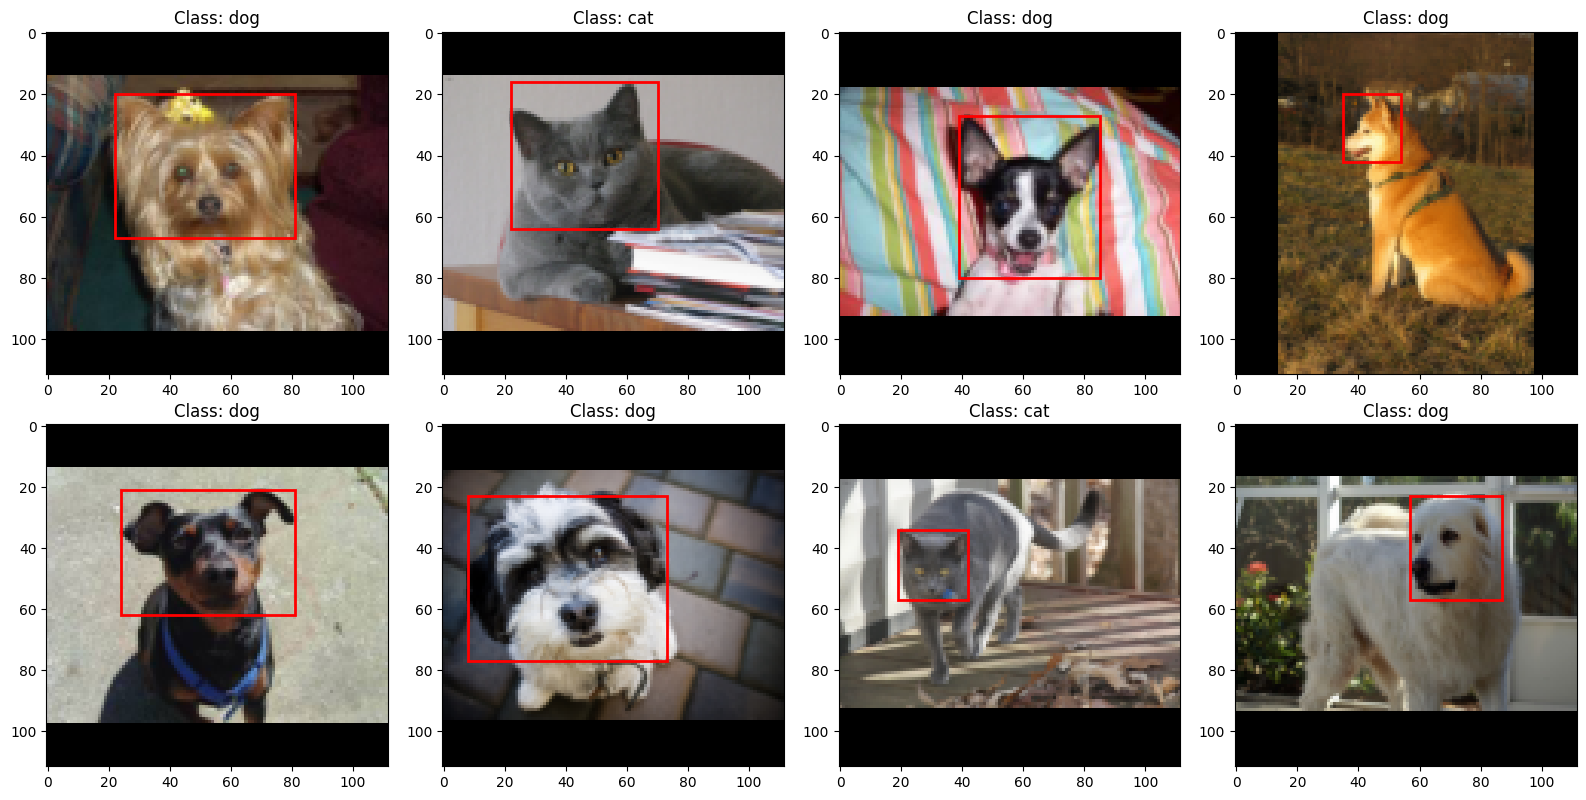

In [12]:
# Setup sample data
num_samples = min(8, len(proc_df))
indices = random.sample(range(len(proc_df)), num_samples)

# Create the figure and grid (2 rows, 4 columns)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()  # Flatten to easily loop with a single index

for i, idx in enumerate(indices):
    row = proc_df.iloc[idx]
    img_p = Path(row['image_path'])
    bbox = (int(row['xmin']), int(row['ymin']), int(row['xmax']), int(row['ymax']))
    visualize_sample(img_p, bbox, ax=axes[i])
    axes[i].set_title(f"Class: {row.get('label', 'N/A')}")

# Clean up layout
plt.tight_layout()
plt.show()

In [13]:
# region Loss Function
### Loss Functions
## This assumes the tensor output of the model is [cat, dog, confidence, x,y,w,h]
## prediction would have [cat, dog, confidence, x,y,w,h]
# https://towardsdatascience.com/yolov1-loss-function-walkthrough-regression-for-all/

# NOTE: Gonna go through the code and clean it up
class coboLoss(nn.Module):
    def __init__(self, S=7, B=1, C=2):
        super(coboLoss, self).__init__()
        self.S = S
        self.B = B
        self.C = C
        self.lambda_coord = 5
        self.lambda_noobj = 0.5
        self.mse = nn.MSELoss(reduction="sum")

    def intersection_over_union(self, boxes_preds, boxes_labels):
        """
        Calculates IoU for the boxes. 
        Expects boxes in [x_center, y_center, width, height] format.
        """
        # Convert from center-relative to corner-relative
        box1_x1 = boxes_preds[..., 0:1] - boxes_preds[..., 2:3] / 2
        box1_y1 = boxes_preds[..., 1:2] - boxes_preds[..., 3:4] / 2
        box1_x2 = boxes_preds[..., 0:1] + boxes_preds[..., 2:3] / 2
        box1_y2 = boxes_preds[..., 1:2] + boxes_preds[..., 3:4] / 2
        
        box2_x1 = boxes_labels[..., 0:1] - boxes_labels[..., 2:3] / 2
        box2_y1 = boxes_labels[..., 1:2] - boxes_labels[..., 3:4] / 2
        box2_x2 = boxes_labels[..., 0:1] + boxes_labels[..., 2:3] / 2
        box2_y2 = boxes_labels[..., 1:2] + boxes_labels[..., 3:4] / 2

        x1 = torch.max(box1_x1, box2_x1)
        y1 = torch.max(box1_y1, box2_y1)
        x2 = torch.min(box1_x2, box2_x2)
        y2 = torch.min(box1_y2, box2_y2)

        intersection = (x2 - x1).clamp(0) * (y2 - y1).clamp(0)
        box1_area = torch.abs(boxes_preds[..., 2:3] * boxes_preds[..., 3:4])
        box2_area = torch.abs(boxes_labels[..., 2:3] * boxes_labels[..., 3:4])

        return intersection / (box1_area + box2_area - intersection + 1e-6)

    def forward(self, predictions, target_label, target_box):
        # predictions shape: [batch, S*S*(C+5)] -> [batch, 7, 7, 7]
        predictions = predictions.reshape(-1, self.S, self.S, self.C + 5)
        batch_size = predictions.shape[0]

        target_grid = torch.zeros_like(predictions).to(predictions.device)
        exists_box = torch.zeros(batch_size, self.S, self.S, 1).to(predictions.device)
        
        img_size = 112
        t_xmin, t_xmax, t_ymin, t_ymax = target_box[:, 0], target_box[:, 1], target_box[:, 2], target_box[:, 3]
        
        # Standardize ground truth to image-relative [0, 1]
        t_w = (t_xmax - t_xmin) / img_size
        t_h = (t_ymax - t_ymin) / img_size
        t_x = ((t_xmin + t_xmax) / 2) / img_size
        t_y = ((t_ymin + t_ymax) / 2) / img_size

        # Determine responsible grid cells
        cell_i = (t_y * self.S).long().clamp(0, self.S - 1)
        cell_j = (t_x * self.S).long().clamp(0, self.S - 1)

        for b in range(batch_size):
            i, j = cell_i[b], cell_j[b]
            exists_box[b, i, j, 0] = 1
            target_grid[b, i, j, target_label[b].long()] = 1
            # BBox coordinates relative to cell (x, y) and image (w, h)
            x_cell = t_x[b] * self.S - j
            y_cell = t_y[b] * self.S - i
            target_grid[b, i, j, 3:7] = torch.tensor([x_cell, y_cell, t_w[b], t_h[b]])

        # Calculate IoU between prediction and target for the cells containing objects
        # We only care about the cells where exists_box == 1
        iou = self.intersection_over_union(
            predictions[..., 3:7], 
            target_grid[..., 3:7]
        )
        target_confidence = exists_box * iou

        # Coordinate Loss (x, y)
        xy_loss = self.mse(
            exists_box * predictions[..., 3:5],
            exists_box * target_grid[..., 3:5]
        )

        # Size Loss (sqrt(w), sqrt(h))
        wh_loss = self.mse(
            exists_box * torch.sign(predictions[..., 5:7]) * torch.sqrt(torch.abs(predictions[..., 5:7]) + 1e-6),
            exists_box * torch.sqrt(target_grid[..., 5:7])
        )

        # Object Confidence Loss (Target is now the calculated IoU)
        obj_loss = self.mse(
            exists_box * predictions[..., 2:3],
            target_confidence
        )

        # No Object Loss
        no_obj_loss = self.mse(
            (1 - exists_box) * predictions[..., 2:3],
            (1 - exists_box) * target_grid[..., 2:3] # target is 0 here
        )

        # Class Loss
        class_loss = self.mse(
            exists_box * predictions[..., :2],
            exists_box * target_grid[..., :2]
        )

        total_loss = (
            self.lambda_coord * (xy_loss + wh_loss)
            + obj_loss
            + self.lambda_noobj * no_obj_loss
            + class_loss
        )

        return total_loss / batch_size
# endregion



In [14]:
def train_model(
    model_class,
    train_loader: DataLoader,
    val_loader: DataLoader,
    device: torch.device,
    best_hyperparams: Dict[str, Any],
    epochs: int = 20,
    early_stopping: bool = True,
    patience: int = 3,
    monitor: str = "val_loss",
) -> Tuple[nn.Module, Dict[str, List[float]]]:
    
    opt_name = best_hyperparams["optimizer"]
    lr = best_hyperparams["learning_rate"]
    wd = best_hyperparams["weight_decay"]
    bs = best_hyperparams["batch_size"]

    # History dictionary for plotting
    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": [],
        "lr": []
    }
    # Best-model tracking (metric-aware)
    monitor_lower_is_better = monitor == "val_loss"
    best_metric = float("inf") if monitor_lower_is_better else 0.0
    best_weights = None
    best_epoch = 0
    epochs_without_improvement = 0
    converged = False

    if early_stopping:
        print(
            f"Early stopping enabled: monitor={monitor}, "
            f"patience={patience}, max_epochs={epochs}"
        )


    # Update data loaders if batch size changed
    train_loader_new = train_loader
    val_loader_new = val_loader
    if bs != train_loader.batch_size:
        train_loader_new = DataLoader(
            train_loader.dataset, batch_size=bs, shuffle=True,
            num_workers=getattr(train_loader, "num_workers", 0), pin_memory=True
        )
        val_loader_new = DataLoader(
            val_loader.dataset, batch_size=bs, shuffle=False,
            num_workers=getattr(val_loader, "num_workers", 0), pin_memory=True
        )

    model = model_class()
    model.to(device)

    if opt_name.lower() == "adam":
        optimizer = Adam(model.parameters(), lr=lr, weight_decay=wd)
    elif opt_name.lower() == "sgd":
        optimizer = SGD(model.parameters(), lr=lr, weight_decay=wd, momentum=0.9)
    elif opt_name.lower() == "rmsprop":
        optimizer = RMSprop(model.parameters(), lr=lr, weight_decay=wd)
    else:
        raise ValueError(f"Unsupported optimizer: {opt_name}")

    criterion = coboLoss()
    scheduler = StepLR(optimizer, step_size=5, gamma=0.5)

    best_val_acc = 0.0
    best_weights = None

    for epoch in range(epochs):
        t0 = time.time()
        
        train_loss, train_acc = train_one_epoch(model, train_loader_new, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader_new, criterion, device)
        
        current_lr = optimizer.param_groups[0]["lr"]
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)

        # Track best model based on monitored metric
        current_metric = val_loss if monitor_lower_is_better else val_acc
        improved = (
            current_metric < best_metric
            if monitor_lower_is_better
            else current_metric > best_metric
        )

        if improved:
            best_metric = current_metric
            best_weights = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        # Early stopping check
        if early_stopping and epochs_without_improvement >= patience:
            print(
                f"\nConverged: {monitor} has not improved for "
                f"{patience} epochs (best {monitor}="
                f"{best_metric:.4f} at epoch {best_epoch})"
            )
            converged = True
            break
        scheduler.step()
        
        elapsed = time.time() - t0
        print(f"Epoch {epoch + 1:>3d}/{epochs} | LR {current_lr:.6f} | "
                f"Train Loss {train_loss:.4f} Acc {train_acc:6.2f}% | "
                f"Val Loss {val_loss:.4f} Acc {val_acc:6.2f}% | {elapsed:.1f}s")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())
    
    # Summary
    if early_stopping and not converged:
        print(
            f"\nReached max epochs ({epochs}) without convergence. "
            f"Best {monitor}={best_metric:.4f} at epoch {best_epoch}."
        )

    if best_weights is not None:
        model.load_state_dict(best_weights)
        print(f"Restored best model with validation accuracy: {best_val_acc:.2f}%")
        
    return model, history

In [15]:
# Train final model with best hyperparameters from search
def train_final_model(
    model_class,
    train_loader: DataLoader,
    val_loader: DataLoader,
    device: torch.device,
    best_hyperparams: Dict[str, Any],
    epochs: int = 20,
) -> nn.Module:
    """
    Train the final model using the best hyperparameters found in the search.
    """
    opt_name = best_hyperparams["optimizer"]
    lr = best_hyperparams["learning_rate"]
    wd = best_hyperparams["weight_decay"]
    bs = best_hyperparams["batch_size"]

    print(f"Training final model with hyperparameters:")
    print(f"Optimizer: {opt_name}, LR: {lr}, Weight Decay: {wd}, Batch Size: {bs}")

    # Update data loaders if batch size changed
    if bs != train_loader.batch_size:
        train_loader_new = DataLoader(
            train_loader.dataset,
            batch_size=bs,
            shuffle=True,
            num_workers=getattr(train_loader, "num_workers", 0),
            pin_memory=True,
        )
        val_loader_new = DataLoader(
            val_loader.dataset,
            batch_size=bs,
            shuffle=False,
            num_workers=getattr(val_loader, "num_workers", 0),
            pin_memory=True,
        )
    else:
        train_loader_new = train_loader
        val_loader_new = val_loader

    # Create model
    model = model_class()
    model.to(device)

    # Setup optimizer
    if opt_name.lower() == "adam":
        optimizer = Adam(model.parameters(), lr=lr, weight_decay=wd)
    elif opt_name.lower() == "sgd":
        optimizer = SGD(model.parameters(), lr=lr, weight_decay=wd, momentum=0.9)
    elif opt_name.lower() == "rmsprop":
        optimizer = RMSprop(model.parameters(), lr=lr, weight_decay=wd)
    else:
        raise ValueError(f"Unsupported optimizer: {opt_name}")

    # Setup loss and scheduler
    criterion = coboLoss()
    scheduler = StepLR(optimizer, step_size=5, gamma=0.5)

    best_val_acc = 0.0
    best_weights = None

    for epoch in range(epochs):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader_new, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader_new, criterion, device)
        scheduler.step()
        elapsed = time.time() - t0
        current_lr = optimizer.param_groups[0]["lr"]
        print(
            f"Epoch {epoch + 1:>3d}/{epochs} | "
            f"LR {current_lr:.6f} | "
            f"Train Loss {train_loss:.4f}  Acc {train_acc:6.2f}% | "
            f"Val Loss {val_loss:.4f}  Acc {val_acc:6.2f}% | "
            f"{elapsed:.1f}s"
        )
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())
    if best_weights is not None:
        model.load_state_dict(best_weights)
        print(f"Restored best model with validation accuracy: {best_val_acc:.2f}%")
    return model

In [16]:
class CatDogDataset(Dataset):
    def __init__(
        self,
        image_paths,
        labels,
        bbox,
        transform=None,
        augment: bool = False,
        flip_prob: float = 0.5,
        img_size: int = 112,
    ):
        self.image_paths = image_paths
        self.labels = labels
        self.bbox = bbox
        self.transform = transform
        self.augment = augment
        self.flip_prob = flip_prob
        self.img_size = img_size

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        try:
            # Load image only when requested
            img_path = self.image_paths[idx]
            image = Image.open(img_path).convert("RGB")
            label = self.labels[idx]
            bbox = torch.tensor(self.bbox[idx], dtype=torch.float32)

            if self.transform:
                image = self.transform(image)

            # --- Data augmentation (training only) ---
            # NOTE: Any geometric transform must update bboxes too.
            # We keep this bbox-safe (plus one bbox-aware flip).
            if self.augment and torch.rand(1).item() < self.flip_prob:
                # image: Tensor[C,H,W]
                image = torch.flip(image, dims=[2])
                xmin, xmax, ymin, ymax = bbox.tolist()
                W = float(self.img_size)
                bbox = torch.tensor([W - xmax, W - xmin, ymin, ymax], dtype=torch.float32)

            return image, label, bbox
        except Exception:
            # If an image is corrupt, return a blank tensor and default bbox to keep batches consistent
            img = torch.zeros((3, 112, 112), dtype=torch.float32)
            label = self.labels[idx]
            try:
                bbox = torch.tensor(self.bbox[idx], dtype=torch.float32)
            except Exception:
                bbox = torch.zeros(4, dtype=torch.float32)
            return img, label, bbox


# Define transforms
# - train_transform: photometric augmentation only (bbox-safe) + normalization
# - eval_transform: deterministic resize + normalization
train_transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Backwards-compatible name used elsewhere in the notebook
transform = eval_transform

In [17]:

# Build train/val file lists and numeric labels from processed data
combined = pd.concat([train_processed_df, val_processed_df], ignore_index=True)
labels = sorted(combined['label'].unique())
label_map = {lab: i for i, lab in enumerate(labels)}

train_files = train_processed_df['image_path'].tolist()
train_labels = train_processed_df['label'].map(label_map).tolist()
train_bbox = [[a, b, c, d] for a, b, c, d in zip(train_processed_df['xmin'], 
                                                train_processed_df['xmax'], 
                                                train_processed_df['ymin'], 
                                                train_processed_df['ymax'])]

val_files = val_processed_df['image_path'].tolist()
val_labels = val_processed_df['label'].map(label_map).tolist()
val_bbox = [[a, b, c, d] for a, b, c, d in zip(val_processed_df['xmin'], 
                                            val_processed_df['xmax'], 
                                            val_processed_df['ymin'], 
                                            val_processed_df['ymax'])]



# Create datasets
train_dataset = CatDogDataset(train_files, train_labels, train_bbox, transform=train_transform, augment=True)
val_dataset = CatDogDataset(val_files, val_labels, val_bbox, transform=eval_transform, augment=False)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [18]:
# Define hyperparameters
best_hps = {
    "optimizer": "adam",
    "learning_rate": 0.0005,
    "weight_decay": 1e-4,
    "batch_size": 8
}

model = coboCNN().to(device)
criterion = coboLoss()

# Train the model and get history
final_model, history = train_model(
    coboCNN, 
    train_loader, 
    val_loader, 
    device, 
    best_hps, 
    epochs=50,
    early_stopping=True, 
    patience=5,
    monitor="val_loss"
)

# Plot the results
plot_training_curves(history, model_name="coboCNN_Final")
plot_lr_schedule(history["lr"])

# Save the model weights
torch.save(final_model.state_dict(), os.path.join(RESULTS_DIR, "final_model_weights.pth"))

Early stopping enabled: monitor=val_loss, patience=5, max_epochs=50
Epoch   1/50 | LR 0.000500 | Train Loss 3.0563 Acc  67.75% | Val Loss 1.5656 Acc  67.75% | 14.3s
Epoch   2/50 | LR 0.000500 | Train Loss 2.1693 Acc  67.79% | Val Loss 1.3889 Acc  67.48% | 13.6s
Epoch   3/50 | LR 0.000500 | Train Loss 2.0018 Acc  67.79% | Val Loss 1.3332 Acc  68.02% | 13.7s
Epoch   4/50 | LR 0.000500 | Train Loss 1.9178 Acc  68.19% | Val Loss 1.2967 Acc  68.43% | 14.3s
Epoch   5/50 | LR 0.000500 | Train Loss 1.8971 Acc  68.43% | Val Loss 1.2555 Acc  67.75% | 14.6s
Epoch   6/50 | LR 0.000250 | Train Loss 1.7972 Acc  69.04% | Val Loss 1.2201 Acc  70.05% | 15.0s
Epoch   7/50 | LR 0.000250 | Train Loss 1.7739 Acc  70.13% | Val Loss 1.2159 Acc  69.78% | 14.8s
Epoch   8/50 | LR 0.000250 | Train Loss 1.7769 Acc  69.38% | Val Loss 1.2218 Acc  71.00% | 14.4s
Epoch   9/50 | LR 0.000250 | Train Loss 1.7056 Acc  70.80% | Val Loss 1.2061 Acc  69.92% | 14.1s
Epoch  10/50 | LR 0.000250 | Train Loss 1.7119 Acc  70.36% 

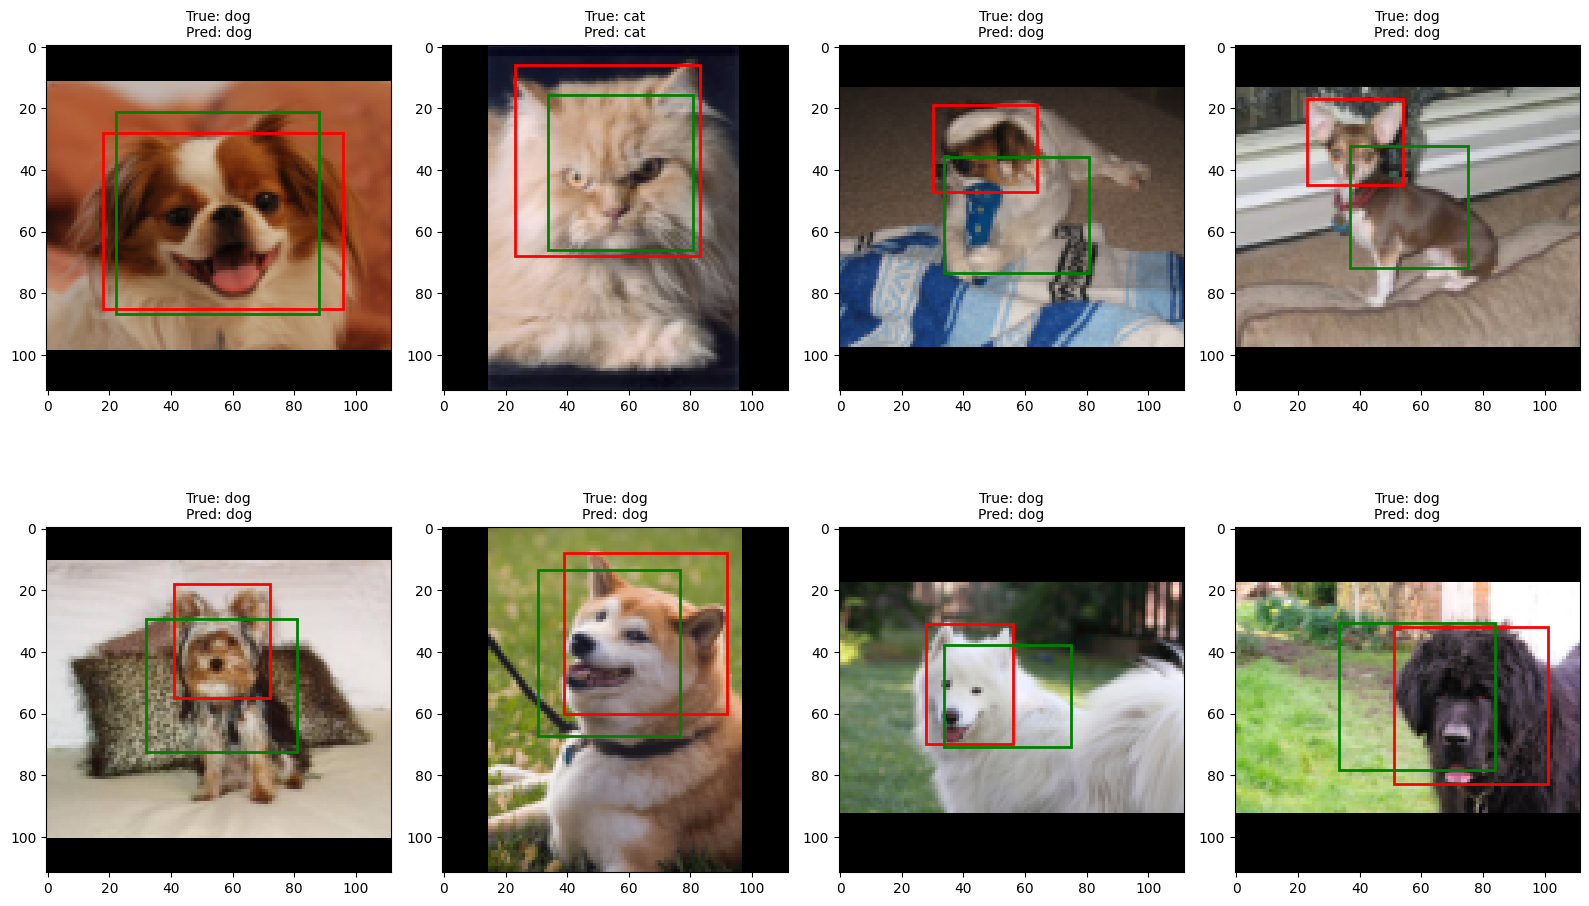

In [19]:
import matplotlib.patches as patches

# Test output model on a few samples
num_samples = min(8, len(val_dataset))
indices = random.sample(range(len(val_dataset)), num_samples)
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

img_size = 112 # De resolutie die je model gebruikt
S = 7          # Grid grootte

for i, idx in enumerate(indices):
    img_path = val_files[idx]
    label = val_labels[idx]
    
    # 1. Preprocessing
    image = Image.open(img_path).convert("RGB")
    original_w, original_h = image.size
    image_input = image.resize((img_size, img_size))
    image_tensor = transform(image_input).unsqueeze(0).to(device)

    # 2. Model voorspelling
    with torch.no_grad():
        output = final_model(image_tensor)
        # Reshape naar [Batch, Grid, Grid, Waarden] -> [1, 7, 7, 7]
        output_reshaped = output.reshape(1, S, S, 7)
        
        # Haal klasse en confidence op
        pred_class_scores = output_reshaped[0, :, :, :2] # [7, 7, 2]
        confidence_scores = output_reshaped[0, :, :, 2]  # [7, 7]
        
        # Bepaal de klasse (sommeren over grid zoals in je originele code)
        preds = pred_class_scores.sum(dim=(0,1)).argmax(dim=0).item()
        
        # Bepaal de BESTE grid cel (hoogste confidence) voor de box
        best_cell = torch.argmax(confidence_scores)
        cell_i = best_cell // S
        cell_j = best_cell % S
        
        # Haal de box data uit die specifieke cel
        # Index 3:6 bevatten [x_cell, y_cell, w, h] volgens je loss functie
        box_data = output_reshaped[0, cell_i, cell_j, 3:7].cpu().numpy()
        
        # 3. Omrekenen van grid naar pixel coördinaten
        # Gebruik .item() om van GPU Tensor naar Python float te gaan
        p_x_cell = box_data[0].item()
        p_y_cell = box_data[1].item()
        p_w      = box_data[2].item()
        p_h      = box_data[3].item()
        
        # Terugrekenen naar image-relative [0, 1]
        p_x_img = (p_x_cell + cell_j.item()) / S
        p_y_img = (p_y_cell + cell_i.item()) / S
        
        # Omzetten naar pixels (denormaliseren)
        p_xmin = (p_x_img - p_w / 2) * original_w
        p_ymin = (p_y_img - p_h / 2) * original_h
        p_xmax = (p_x_img + p_w / 2) * original_w
        p_ymax = (p_y_img + p_h / 2) * original_h

    # 4. Visualisatie
    # Teken eerst de afbeelding en de TRUE box (Rood)
    true_bbox = (
        int(val_processed_df.iloc[idx]['xmin']),
        int(val_processed_df.iloc[idx]['ymin']),
        int(val_processed_df.iloc[idx]['xmax']),
        int(val_processed_df.iloc[idx]['ymax'])
    )
    visualize_sample(img_path, true_bbox, ax=axes[i]) # Dit tekent de rode box
    
    # Teken de PREDICTED box (Groen)
    rect = patches.Rectangle(
        (p_xmin, p_ymin), p_xmax - p_xmin, p_ymax - p_ymin, 
        linewidth=2, edgecolor='g', facecolor='none', label='Pred'
    )
    axes[i].add_patch(rect)
    
    axes[i].set_title(f"True: {labels[label]}\nPred: {labels[preds]}", fontsize=10)

plt.tight_layout()
plt.show()

In [20]:
def calculate_iou(box1, box2):
    """Calculates IoU between two boxes: [xmin, ymin, xmax, ymax]"""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection
    
    return intersection / (union + 1e-6)

def decode_predictions(output, threshold, S=7, C=2):
    """Converts 7x7x7 output to a list of detections: [class_id, score, xmin, ymin, xmax, ymax]"""
    output = output.reshape(S, S, C + 5)
    detections = []
    
    for i in range(S):
        for j in range(S):
            conf = output[i, j, 2].item()
            if conf > threshold:
                # Class prediction
                class_id = torch.argmax(output[i, j, :2]).item()
                
                # Box coordinates (relative to cell -> relative to image)
                x_cell, y_cell, w, h = output[i, j, 3:7].detach().cpu().numpy()
                
                # Convert cell-relative (0-1) to image-relative (0-112)
                x_img = (x_cell + j) / S * 112
                y_img = (y_cell + i) / S * 112
                w_img = w * 112
                h_img = h * 112
                
                xmin, ymin = x_img - w_img/2, y_img - h_img/2
                xmax, ymax = x_img + w_img/2, y_img + h_img/2
                
                detections.append([class_id, conf, xmin, ymin, xmax, ymax])
    return detections

F1 Scores at different thresholds: [0.7638186220889596, 0.2655695248424391, 0.03723397569613368, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


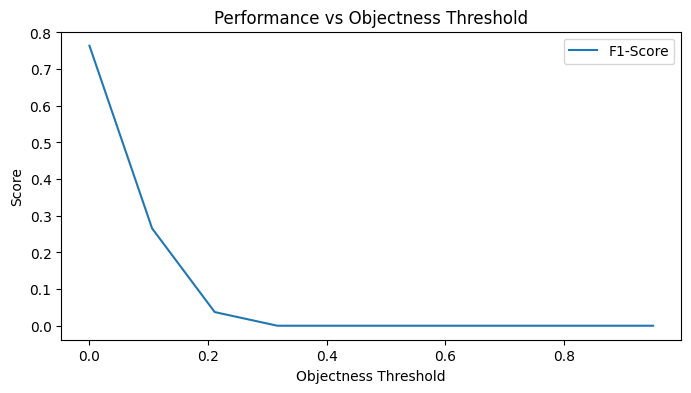

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

thresholds = np.linspace(0, 0.95, 10)
map_scores = []
f1_scores = []
all_results = []

for thresh in thresholds:
    y_true = []
    y_pred = []
    tp, fp, fn = 0, 0, 0
    
    for images, labels, bboxes in val_loader:
        images = images.to(device)
        with torch.no_grad():
            outputs = final_model(images)
            
        for b in range(outputs.shape[0]):
            preds = decode_predictions(outputs[b], thresh)
            gt_box = bboxes[b].cpu().numpy() # [xmin, xmax, ymin, ymax] -> adjust format
            gt_box_corr = [gt_box[0], gt_box[2], gt_box[1], gt_box[3]]
            gt_class = labels[b].item()
            
            # find if any pred matches GT
            match = False
            for p in preds:
                iou = calculate_iou(p[2:], gt_box_corr)
                if iou >= 0.5 and p[0] == gt_class:
                    match = True
                    y_pred.append(p[0])
                    y_true.append(gt_class)
                    break
            
            if match: tp += 1
            elif len(preds) > 0: fp += 1
            else: 
                fn += 1
                y_true.append(gt_class)
                y_pred.append(2) # 'Background/No Detection' class
                
    precision = tp / (tp + fp + 1e-6)
    recall = tp / (tp + fn + 1e-6)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-6)
    
    f1_scores.append(f1)
    all_results.append((y_true, y_pred))

# Plot mAP/F1 curve
print("F1 Scores at different thresholds:", f1_scores)  
plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_scores, label='F1-Score')
plt.xlabel('Objectness Threshold')
plt.ylabel('Score')
plt.title('Performance vs Objectness Threshold')
plt.legend()
plt.show()

In [26]:
# --- Training / Validation / Test mAP table ---
# Pure-Python VOC-style mAP@0.5 (no pycocotools needed).
# Uses `decode_predictions` defined above (YOLO-style 7x7 grid).

import numpy as np
import torch
from pathlib import Path
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from IPython.display import Markdown, display

# Keep low threshold so AP can rank predictions by confidence
OBJECTNESS_THRESHOLD = 0.05
IOU_THRESHOLD = 0.5
NUM_CLASSES = 2  # cat, dog
TOPK_PER_IMAGE = 50  # cap predictions per image for speed (max 49 anyway)

# Make the cell runnable even if you didn't rerun training in this session
if "device" not in globals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if "final_model" not in globals():
    if "coboCNN" not in globals():
        raise RuntimeError("coboCNN not found. Run the model-definition cells first.")
    final_model = coboCNN().to(device)
    candidates = []
    if "RESULTS_DIR" in globals():
        candidates.append(Path(RESULTS_DIR) / "final_model_weights.pth")
    candidates += [
        Path("results") / "final_model_weights.pth",
        Path("notebooks") / "results" / "final_model_weights.pth",
    ]
    weights_path = next((p for p in candidates if p.exists()), None)
    if weights_path is None:
        raise RuntimeError(
            "final_model not found, and no weights file found. Expected one of: "
            + ", ".join(str(p) for p in candidates)
        )
    final_model.load_state_dict(torch.load(weights_path, map_location=device))
    final_model.eval()

if "decode_predictions" not in globals():
    raise RuntimeError("decode_predictions not found. Run the cell that defines it first.")


def _box_iou_xyxy(box_a, box_b):
    # box_*: [xmin, ymin, xmax, ymax]
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b
    ix1 = max(ax1, bx1)
    iy1 = max(ay1, by1)
    ix2 = min(ax2, bx2)
    iy2 = min(ay2, by2)
    iw = max(0.0, ix2 - ix1)
    ih = max(0.0, iy2 - iy1)
    inter = iw * ih
    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    union = area_a + area_b - inter
    return inter / (union + 1e-12)


def _compute_ap(recalls, precisions):
    # Continuous AP (VOC 2010+ style)
    if recalls.size == 0:
        return 0.0
    mrec = np.concatenate(([0.0], recalls, [1.0]))
    mpre = np.concatenate(([0.0], precisions, [0.0]))
    for i in range(mpre.size - 1, 0, -1):
        mpre[i - 1] = max(mpre[i - 1], mpre[i])
    idx = np.where(mrec[1:] != mrec[:-1])[0]
    return float(np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1]))


@torch.no_grad()
def compute_map50(model, loader, device, conf_threshold=0.05, iou_threshold=0.5, num_classes=2, topk_per_image=50):
    model.eval()
    per_image = []  # [(gt_class, gt_box_xyxy, dets)]
    for images, labels, bboxes in loader:
        images = images.to(device)
        outputs = model(images).detach().cpu()
        for b in range(outputs.shape[0]):
            dets = decode_predictions(outputs[b], threshold=conf_threshold, S=7, C=2)
            # dets: [class_id, score, xmin, ymin, xmax, ymax] in 112x112 coords
            dets = sorted(dets, key=lambda d: float(d[1]), reverse=True)
            if topk_per_image is not None:
                dets = dets[: int(topk_per_image)]
            gt_cls = int(labels[b].item())
            bb = bboxes[b].detach().cpu().float().tolist()  # [xmin, xmax, ymin, ymax]
            gt_xmin, gt_xmax, gt_ymin, gt_ymax = bb
            gt_box = [gt_xmin, gt_ymin, gt_xmax, gt_ymax]
            per_image.append((gt_cls, gt_box, dets))

    aps = []
    for cls in range(num_classes):
        scores = []
        tps = []
        num_gt = sum(1 for (gt_cls, _, _) in per_image if gt_cls == cls)
        if num_gt == 0:
            continue
        for gt_cls, gt_box, dets in per_image:
            dets_cls = [d for d in dets if int(d[0]) == cls]
            dets_cls = sorted(dets_cls, key=lambda d: float(d[1]), reverse=True)
            matched = False
            for d in dets_cls:
                scores.append(float(d[1]))
                if gt_cls != cls:
                    tps.append(0)
                    continue
                pred_box = [float(v) for v in d[2:]]
                # clamp to image bounds
                pred_box = [
                    max(0.0, min(112.0, pred_box[0])),
                    max(0.0, min(112.0, pred_box[1])),
                    max(0.0, min(112.0, pred_box[2])),
                    max(0.0, min(112.0, pred_box[3])),
                ]
                iou = _box_iou_xyxy(pred_box, gt_box)
                if (not matched) and (iou >= iou_threshold):
                    tps.append(1)
                    matched = True
                else:
                    tps.append(0)

        if len(scores) == 0:
            aps.append(0.0)
            continue
        order = np.argsort(np.asarray(scores))[::-1]
        tps_sorted = np.asarray(tps, dtype=np.float64)[order]
        fps_sorted = 1.0 - tps_sorted
        cum_tp = np.cumsum(tps_sorted)
        cum_fp = np.cumsum(fps_sorted)
        recalls = cum_tp / (num_gt + 1e-12)
        precisions = cum_tp / (cum_tp + cum_fp + 1e-12)
        aps.append(_compute_ap(recalls, precisions))

    return float(np.mean(aps)) if len(aps) else 0.0


def _ensure_test_split():
    # Build a test split if it doesn't exist already
    global test_loader, val_loader_eval
    if "test_loader" in globals():
        if "val_loader" in globals():
            val_loader_eval = val_loader
        return
    if "val_processed_df" not in globals():
        raise RuntimeError("val_processed_df not found. Run the data-prep cells first.")
    if "label_map" not in globals():
        raise RuntimeError("label_map not found. Run the data-prep cells first.")
    if "CatDogDataset" not in globals() or "transform" not in globals():
        raise RuntimeError("CatDogDataset/transform not found. Run the dataset cells first.")

    # Split current validation set into validation+test (50/50), stratified by class
    val_eval_df, test_df = train_test_split(
        val_processed_df,
        test_size=0.5,
        stratify=val_processed_df["label"],
        random_state=42,
    )

    def _df_to_dataset(df):
        files = df["image_path"].tolist()
        labels_ = df["label"].map(label_map).tolist()
        bbox_ = [
            [a, b, c, d]
            for a, b, c, d in zip(df["xmin"], df["xmax"], df["ymin"], df["ymax"])
        ]
        return CatDogDataset(files, labels_, bbox_, transform=transform)

    val_eval_dataset = _df_to_dataset(val_eval_df)
    test_dataset = _df_to_dataset(test_df)

    bs = getattr(val_loader, "batch_size", 32) if "val_loader" in globals() else 32
    val_loader_eval = DataLoader(val_eval_dataset, batch_size=bs, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=bs, shuffle=False)


_ensure_test_split()

if "train_loader" not in globals() or "val_loader_eval" not in globals() or "test_loader" not in globals():
    raise RuntimeError("Expected train_loader, val_loader, and test_loader to be defined.")

train_map = compute_map50(
    final_model, train_loader, device,
    conf_threshold=OBJECTNESS_THRESHOLD, iou_threshold=IOU_THRESHOLD,
    num_classes=NUM_CLASSES, topk_per_image=TOPK_PER_IMAGE,
)
val_map = compute_map50(
    final_model, val_loader_eval, device,
    conf_threshold=OBJECTNESS_THRESHOLD, iou_threshold=IOU_THRESHOLD,
    num_classes=NUM_CLASSES, topk_per_image=TOPK_PER_IMAGE,
)
test_map = compute_map50(
    final_model, test_loader, device,
    conf_threshold=OBJECTNESS_THRESHOLD, iou_threshold=IOU_THRESHOLD,
    num_classes=NUM_CLASSES, topk_per_image=TOPK_PER_IMAGE,
)

table = (
    "Training, validation and test mAP\n"
    "| Setting | mAP |\n"
    "| Training | {:.4f} |\n"
    "| Validation | {:.4f} |\n"
    "| Test | {:.4f} |\n"
).format(train_map, val_map, test_map)

display(Markdown(table))
print(table)

Training, validation and test mAP
| Setting | mAP |
| Training | 0.1750 |
| Validation | 0.1152 |
| Test | 0.1089 |


Training, validation and test mAP
| Setting | mAP |
| Training | 0.1750 |
| Validation | 0.1152 |
| Test | 0.1089 |



Starting grid-based threshold sweep...
Thresh: 0.5 | F1: 0.7075 | Precision: 0.5474
Thresh: 0.5 | F1: 0.7075 | Precision: 0.5474
Thresh: 0.6 | F1: 0.7075 | Precision: 0.5474
Thresh: 0.6 | F1: 0.7075 | Precision: 0.5474
Thresh: 0.7 | F1: 0.7075 | Precision: 0.5474
Thresh: 0.7 | F1: 0.6141 | Precision: 0.5496
Thresh: 0.8 | F1: 0.0000 | Precision: 0.0000
Thresh: 0.8 | F1: 0.0000 | Precision: 0.0000
Thresh: 0.9 | F1: 0.0000 | Precision: 0.0000
Thresh: 0.9 | F1: 0.0000 | Precision: 0.0000


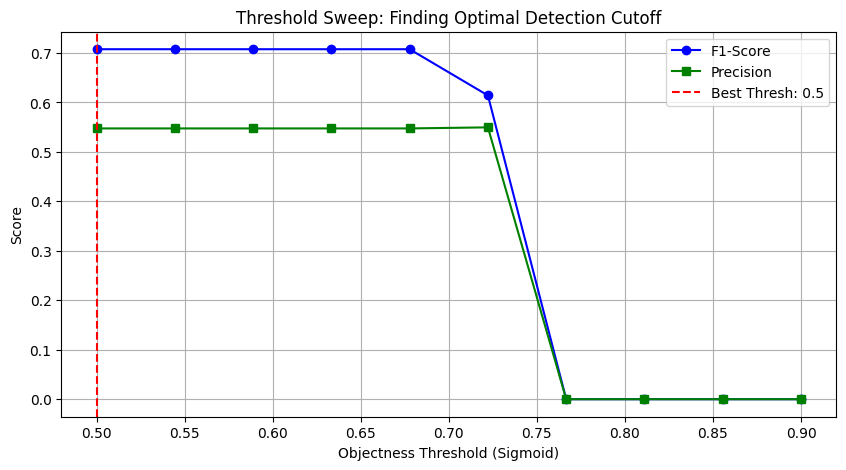


--- Best Results at Threshold 0.5 ---


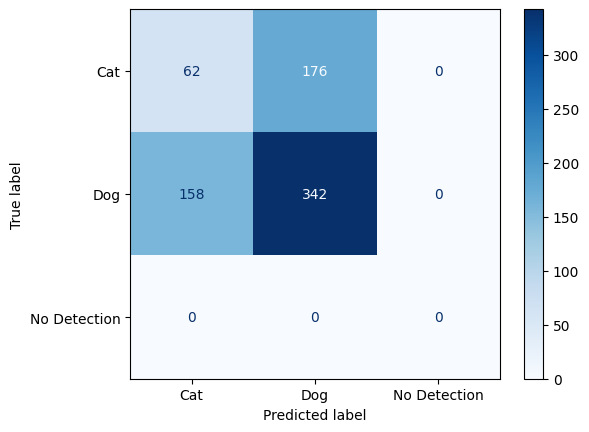

In [23]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_score

def get_best_prediction(output_tensor, threshold=0.5):
    # 1. Reshape from flattened 343 to (7, 7, 7) grid
    # Depth 0-1: Class logits, Depth 2: Objectness, Depth 3-6: Bbox coords
    grid = output_tensor.reshape(7, 7, 7)
    
    # 2. Apply Sigmoid to the Objectness score (Index 2) 
    # This turns raw logits into a 0.0 to 1.0 probability
    obj_probs = torch.sigmoid(grid[:, :, 2]) 
    
    best_conf = -1
    best_pred = None 
    
    for i in range(7):
        for j in range(7):
            conf = obj_probs[i, j].item() 
            if conf > threshold and conf > best_conf:
                best_conf = conf
                # Apply Softmax to class scores (Index 0 and 1) to pick Cat vs Dog
                class_probs = torch.softmax(grid[i, j, :2], dim=0)
                class_id = torch.argmax(class_probs).item()
                best_pred = class_id
                
    return best_pred if best_pred is not None else 2 # 2 = 'No Detection'

def evaluate_threshold_sweep(model, val_loader, device, thresholds=np.linspace(0.5, 0.9, 10)):
    model.eval()
    f1_results = []
    precision_results = []
    all_preds_at_thresh = []
    all_labels_at_thresh = []

    print("Starting grid-based threshold sweep...")
    
    # Pre-calculate all model outputs once to save time
    all_outputs = []
    all_true_labels = []
    with torch.no_grad():
        for images, labels, bboxes in val_loader:
            images = images.to(device)
            outputs = model(images)
            all_outputs.append(outputs.cpu())
            all_true_labels.append(labels)
    
    all_outputs = torch.cat(all_outputs, dim=0)
    all_true_labels = torch.cat(all_true_labels, dim=0)

    for thresh in thresholds:
        y_true = []
        y_pred = []
        tp, fp, fn = 0, 0, 0
        
        for b in range(all_outputs.size(0)):
            p = get_best_prediction(all_outputs[b], threshold=thresh)
            target = all_true_labels[b].item()
            
            y_true.append(target)
            y_pred.append(p)
            
            if p == target:
                tp += 1
            elif p == 2: # Model said "nothing here" but there was an animal
                fn += 1
            else: # Model picked the wrong animal
                fp += 1
        
        precision = tp / (tp + fp + 1e-6)
        recall = tp / (tp + fn + 1e-6)
        f1 = 2 * (precision * recall) / (precision + recall + 1e-6)
        
        f1_results.append(f1)
        precision_results.append(precision)
        all_preds_at_thresh.append(y_pred)
        all_labels_at_thresh.append(y_true)
        
        print(f"Thresh: {thresh:.1f} | F1: {f1:.4f} | Precision: {precision:.4f}")

    # Plotting
    best_idx = np.argmax(f1_results)
    best_thresh = thresholds[best_idx]
    
    plt.figure(figsize=(10, 5))
    plt.plot(thresholds, f1_results, marker='o', label='F1-Score', color='blue')
    plt.plot(thresholds, precision_results, marker='s', label='Precision', color='green')
    plt.axvline(best_thresh, color='red', linestyle='--', label=f'Best Thresh: {best_thresh:.1f}')
    plt.xlabel('Objectness Threshold (Sigmoid)')
    plt.ylabel('Score')
    plt.title('Threshold Sweep: Finding Optimal Detection Cutoff')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Confusion Matrix
    print(f"\n--- Best Results at Threshold {best_thresh:.1f} ---")
    cm_labels = ['Cat', 'Dog', 'No Detection']
    cm = confusion_matrix(all_labels_at_thresh[best_idx], all_preds_at_thresh[best_idx], labels=[0, 1, 2])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cm_labels)
    disp.plot(cmap='Blues')
    plt.show()

# Ensure you use the correct model variable name here (e.g., 'model' or 'final_model')
evaluate_threshold_sweep(model, val_loader, device)

In [24]:
import io
import sys
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from torchsummary import summary
from PIL import Image

# 1. Capture the summary output into a string
stream = io.StringIO()
old_stdout = sys.stdout
sys.stdout = stream

try:
    # Use the input size for your assignment (3, 112, 112)
    summary(final_model, (3, 112, 112))
finally:
    sys.stdout = old_stdout

summary_str = stream.getvalue()

# 2. Print the normal summary for your own verification
print("--- STANDARD MODEL SUMMARY ---")
print(summary_str)

# 3. Use Matplotlib to plot the text as an image
# We use a monospaced font like 'Courier' or 'monospace' to fix alignment.
plt.figure(figsize=(10, 8), dpi=150) # Set a good size and high DPI
plt.text(0.01, 1.0, summary_str, 
         fontfamily='monospace', # REQUIRED for table alignment
         fontsize=10, 
         verticalalignment='top', 
         horizontalalignment='left')
plt.axis('off') # Hide axes

# 4. Save the figure as an image
plt.tight_layout()
image_filename = os.path.join(str(RESULTS_DIR), 'model_summary_table.png')
plt.savefig(image_filename, bbox_inches='tight', pad_inches=0)
plt.close() # Close the plot

print(f"\n--- IMAGE EXPORTED AS {image_filename} ---")

--- STANDARD MODEL SUMMARY ---
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 112, 112]             448
       BatchNorm2d-2         [-1, 16, 112, 112]              32
         AvgPool2d-3           [-1, 16, 56, 56]               0
              ReLU-4           [-1, 16, 56, 56]               0
            Conv2d-5           [-1, 32, 56, 56]           4,640
       BatchNorm2d-6           [-1, 32, 56, 56]              64
         AvgPool2d-7           [-1, 32, 28, 28]               0
              ReLU-8           [-1, 32, 28, 28]               0
            Conv2d-9           [-1, 64, 28, 28]          18,496
      BatchNorm2d-10           [-1, 64, 28, 28]             128
        AvgPool2d-11           [-1, 64, 14, 14]               0
             ReLU-12           [-1, 64, 14, 14]               0
           Conv2d-13           [-1, 64, 14, 14]          36,928
      Ba